# Lab 2

## Library Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import FastICA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_predict, cross_val_score, KFold
from math import sqrt
from sklearn.decomposition import PCA
from sklearn.svm import SVR

## Dataset Loading

In [2]:
boston_housing_df = pd.read_csv('/content/boston_housing.csv', index_col=0)

## Exploratory Data Analysis

In [3]:
boston_housing_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [4]:
for col in boston_housing_df.columns:
  print(f'{col}:')
  print(boston_housing_df[col].describe())
  non_zero_count = (boston_housing_df[col] != 0).sum()
  nan_count = boston_housing_df[col].isna().sum()
  total_count = len(boston_housing_df[col])
  percentage_non_zero = (non_zero_count / total_count) * 100
  percentage_nan = (nan_count / total_count) * 100

  print(f"Percentage of non-zero values: {percentage_non_zero:.2f}%")
  print(f"Percentage of NaN values: {percentage_nan:.2f}%")
  print()

CRIM:
count    506.000000
mean       3.613524
std        8.601545
min        0.006320
25%        0.082045
50%        0.256510
75%        3.677083
max       88.976200
Name: CRIM, dtype: float64
Percentage of non-zero values: 100.00%
Percentage of NaN values: 0.00%

ZN:
count    506.000000
mean      11.363636
std       23.322453
min        0.000000
25%        0.000000
50%        0.000000
75%       12.500000
max      100.000000
Name: ZN, dtype: float64
Percentage of non-zero values: 26.48%
Percentage of NaN values: 0.00%

INDUS:
count    506.000000
mean      11.136779
std        6.860353
min        0.460000
25%        5.190000
50%        9.690000
75%       18.100000
max       27.740000
Name: INDUS, dtype: float64
Percentage of non-zero values: 100.00%
Percentage of NaN values: 0.00%

CHAS:
count    506.000000
mean       0.069170
std        0.253994
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: CHAS, dtype: float64
Percentage of n

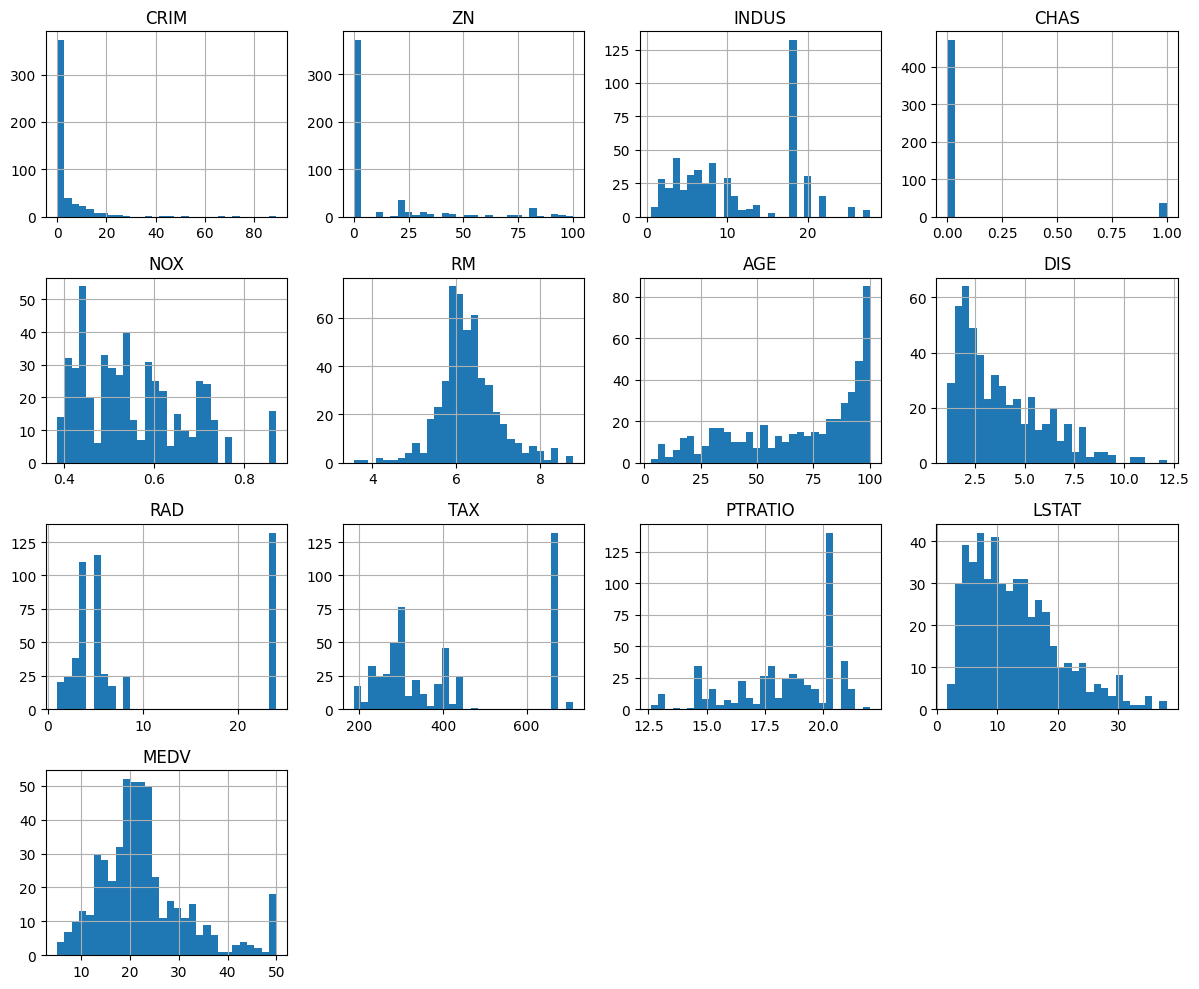

In [5]:
boston_housing_df.hist(bins=30, figsize=(12, 10))
plt.tight_layout()
plt.show()

**CHAS, CRIM and ZN are dropped due to high percentage of zero values**

In [6]:
boston_housing_df = boston_housing_df.drop(columns=['CHAS', 'ZN', 'CRIM'], axis=1)

In [7]:
def check_data_normallity(df):
  for col in df.columns:
    # Calculate skewness and kurtosis
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()

    # Perform Kolmogorov-Smirnov test
    ks_stat, ks_pval = stats.kstest(df[col], 'norm')

    print(f'{col}:')
    print(f'  Skewness: {skewness:.3f}')
    print(f'  Kurtosis: {kurtosis:.3f}')
    print(f'  Kolmogorov-Smirnov Test: Statistic={ks_stat:.3f}, p-value={ks_pval:.3f}')

    # Determine if the distribution is considered normal based on the p-value
    if ks_pval > 0.1:
        print('  Distribution is considered normal.')
    else:
        print('  Distribution is not considered normal.')

In [8]:
check_data_normallity(boston_housing_df)

INDUS:
  Skewness: 0.295
  Kurtosis: -1.234
  Kolmogorov-Smirnov Test: Statistic=0.938, p-value=0.000
  Distribution is not considered normal.
NOX:
  Skewness: 0.729
  Kurtosis: -0.065
  Kolmogorov-Smirnov Test: Statistic=0.650, p-value=0.000
  Distribution is not considered normal.
RM:
  Skewness: 0.404
  Kurtosis: 1.892
  Kolmogorov-Smirnov Test: Statistic=1.000, p-value=0.000
  Distribution is not considered normal.
AGE:
  Skewness: -0.599
  Kurtosis: -0.968
  Kolmogorov-Smirnov Test: Statistic=0.998, p-value=0.000
  Distribution is not considered normal.
DIS:
  Skewness: 1.012
  Kurtosis: 0.488
  Kolmogorov-Smirnov Test: Statistic=0.892, p-value=0.000
  Distribution is not considered normal.
RAD:
  Skewness: 1.005
  Kurtosis: -0.867
  Kolmogorov-Smirnov Test: Statistic=0.938, p-value=0.000
  Distribution is not considered normal.
TAX:
  Skewness: 0.670
  Kurtosis: -1.142
  Kolmogorov-Smirnov Test: Statistic=1.000, p-value=0.000
  Distribution is not considered normal.
PTRATIO:
  Sk

## Normalization

In [9]:
boston_housing_normalized_df = boston_housing_df.copy()
for column in boston_housing_normalized_df.columns:
  if column != 'MEDV':
    scaler = MinMaxScaler()
    boston_housing_normalized_df[column] = scaler.fit_transform(boston_housing_normalized_df[[column]])

## Correlation with MEDV

In [10]:
def show_correlation_with_target(df, target_column):
  correlations = df.drop(target_column, axis=1).corrwith(df[target_column]).sort_values(ascending=False)
  sns.heatmap(correlations.to_frame(name='Correlation'), annot=True)
  plt.title(f'Correlation between Features and {target_column}')
  plt.show()

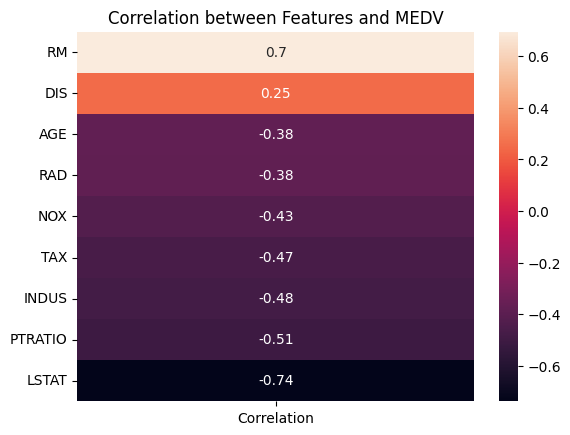

In [11]:
show_correlation_with_target(boston_housing_normalized_df, 'MEDV')

## Transformation to get Normal Distribution

In [12]:
boston_housing_transformed_df = boston_housing_normalized_df.copy()

for column in boston_housing_transformed_df.columns:
  if column != 'MEDV':
    column_series = boston_housing_transformed_df[column]
    try:
      if boston_housing_transformed_df[column].skew() < 0:
        boston_housing_transformed_df[column] = np.exp(column_series)
      if boston_housing_transformed_df[column].skew() > 1:
        boston_housing_transformed_df[column] = np.cbrt(np.sqrt(column_series))
      if boston_housing_transformed_df[column].skew() > 0:
        boston_housing_transformed_df[column] = np.sqrt(column_series)
    except ValueError:
      print(f"Box-Cox transformation failed for column: {column}")

In [13]:
check_data_normallity(boston_housing_transformed_df)

INDUS:
  Skewness: -0.121
  Kurtosis: -1.167
  Kolmogorov-Smirnov Test: Statistic=0.562, p-value=0.000
  Distribution is not considered normal.
NOX:
  Skewness: 0.038
  Kurtosis: -0.741
  Kolmogorov-Smirnov Test: Statistic=0.556, p-value=0.000
  Distribution is not considered normal.
RM:
  Skewness: -0.991
  Kurtosis: 7.184
  Kolmogorov-Smirnov Test: Statistic=0.677, p-value=0.000
  Distribution is not considered normal.
AGE:
  Skewness: -0.330
  Kurtosis: -1.325
  Kolmogorov-Smirnov Test: Statistic=0.847, p-value=0.000
  Distribution is not considered normal.
DIS:
  Skewness: -0.755
  Kurtosis: 2.411
  Kolmogorov-Smirnov Test: Statistic=0.680, p-value=0.000
  Distribution is not considered normal.
RAD:
  Skewness: -1.863
  Kurtosis: 5.977
  Kolmogorov-Smirnov Test: Statistic=0.684, p-value=0.000
  Distribution is not considered normal.
TAX:
  Skewness: 0.182
  Kurtosis: -0.945
  Kolmogorov-Smirnov Test: Statistic=0.559, p-value=0.000
  Distribution is not considered normal.
PTRATIO:
 

## Visualization

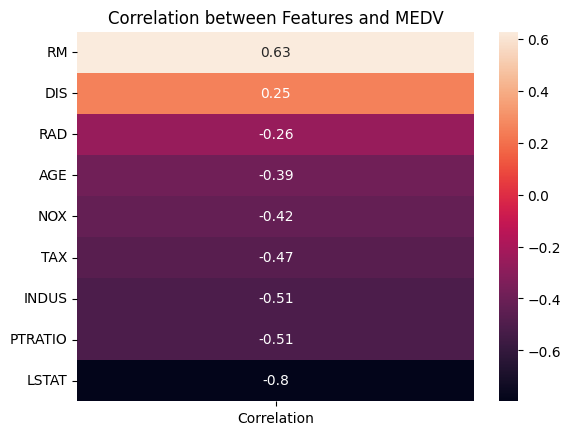

In [14]:
show_correlation_with_target(boston_housing_transformed_df, 'MEDV')

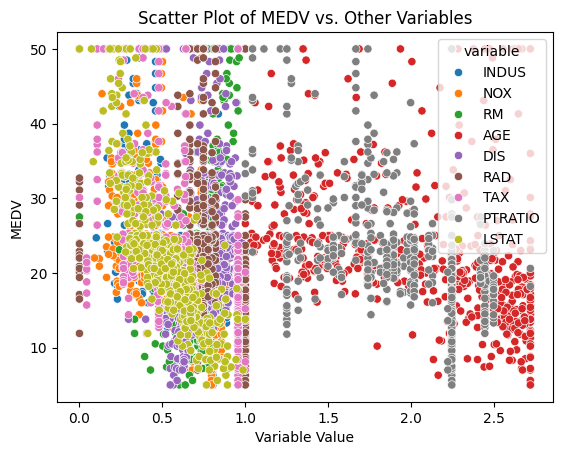

In [15]:
df_melted = boston_housing_transformed_df.melt(id_vars='MEDV')
sns.scatterplot(x='value', y='MEDV', hue='variable', data=df_melted)
plt.xlabel('Variable Value')
plt.ylabel('MEDV')
plt.title('Scatter Plot of MEDV vs. Other Variables')
plt.show()

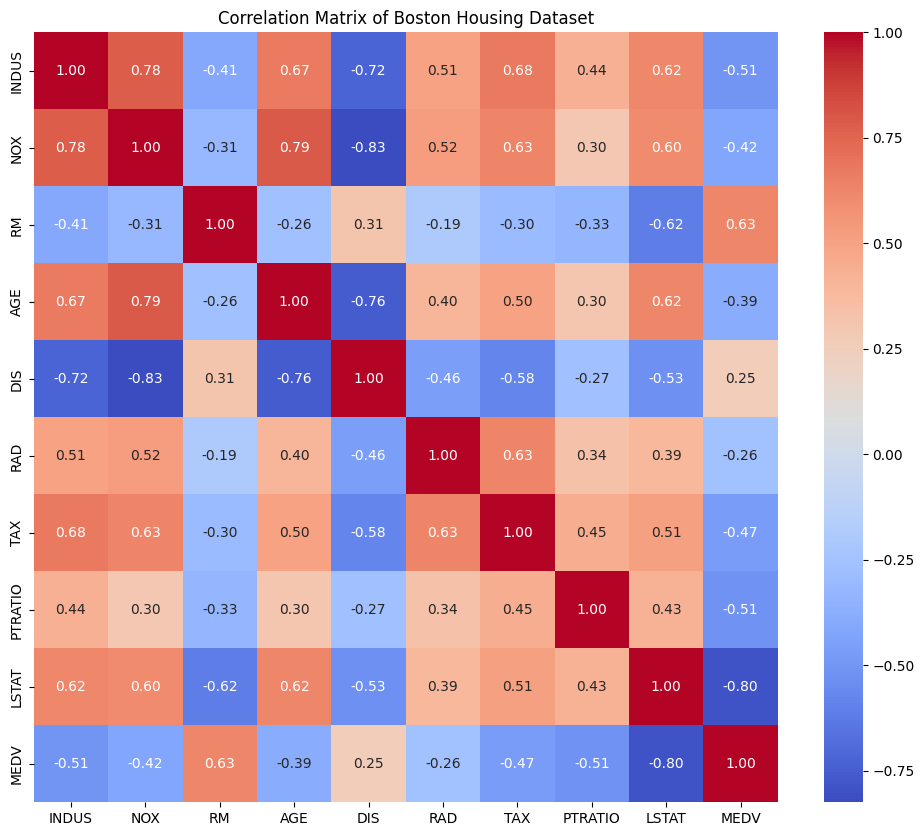

In [16]:
plt.figure(figsize=(12, 10))
sns.heatmap(boston_housing_transformed_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Boston Housing Dataset')
plt.show()

# First Approach

## Principal Component Analysis

This is a technique pupular for being capable of maximizing the variance of the variables is a way to extract the most important features or patterns from the data.

In [52]:
y = boston_housing_transformed_df['MEDV']
X = boston_housing_transformed_df.drop('MEDV', axis=1)

pca = PCA(n_components=None)
X_pca = pca.fit_transform(X)

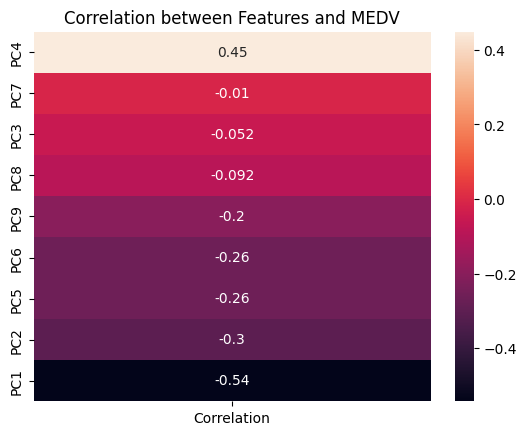

In [53]:
boston_housing_PCA_df = pd.DataFrame(X_pca)
boston_housing_PCA_df.columns = [f'PC{i+1}' for i in range(boston_housing_PCA_df.shape[1])]
boston_housing_PCA_df = pd.concat([boston_housing_PCA_df, boston_housing_transformed_df['MEDV']], axis=1)
show_correlation_with_target(boston_housing_PCA_df, 'MEDV')

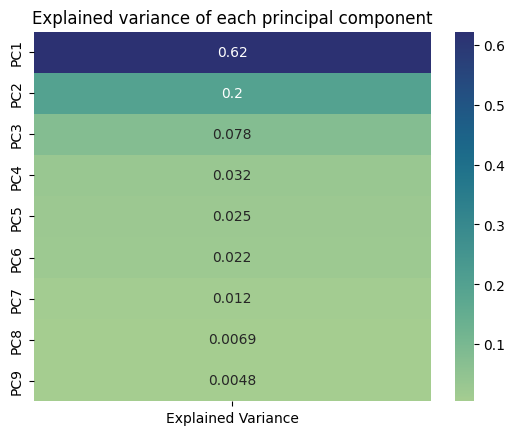

In [54]:
explained_variance_PCA = pd.Series(pca.explained_variance_ratio_, index=[f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))])
sns.heatmap(explained_variance_PCA.to_frame(name='Explained Variance'), annot=True, cmap="crest")
plt.title(f'Explained variance of each principal component')
plt.show()

## Independent Component Analysis

This is a technique pupular for being capable of identifying the independent sources in the data and separate them into independent components.

In [55]:
y = boston_housing_transformed_df['MEDV']
X = boston_housing_transformed_df.drop('MEDV', axis=1)
ica = FastICA(n_components=None)
X_ica = ica.fit_transform(X)

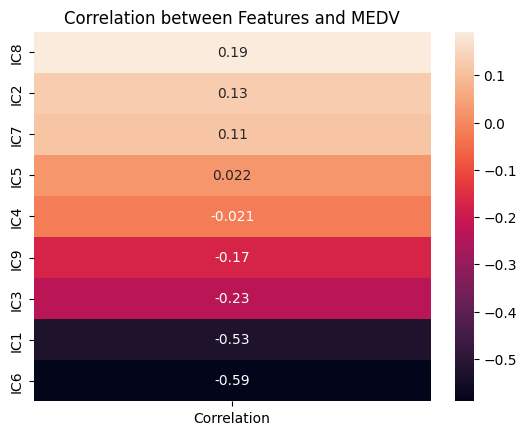

In [56]:
boston_housing_ICA_df = pd.DataFrame(X_ica)
boston_housing_ICA_df.columns = [f'IC{i+1}' for i in range(boston_housing_ICA_df.shape[1])]
boston_housing_ICA_df = pd.concat([boston_housing_ICA_df, boston_housing_transformed_df['MEDV']], axis=1)
show_correlation_with_target(boston_housing_ICA_df, 'MEDV')

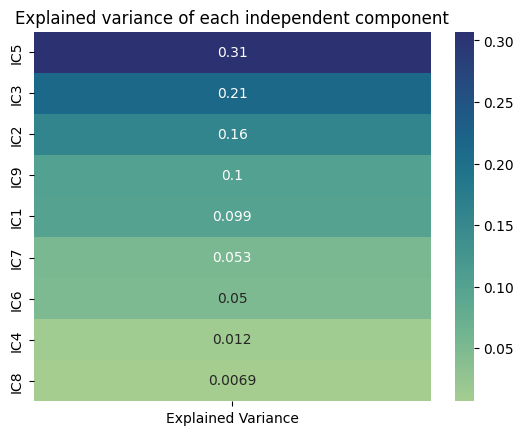

In [57]:
eigenvalues = ica.components_.var(axis=0)
explained_variance_ICA = pd.Series(eigenvalues / eigenvalues.sum(), index=[f'IC{i+1}' for i in range(len(eigenvalues))]).sort_values(ascending=False)
sns.heatmap(explained_variance_ICA.to_frame(name='Explained Variance'), annot=True, cmap="crest")
plt.title(f'Explained variance of each independent component')
plt.show()

In [68]:
boston_housing_selected_components = pd.concat([
    boston_housing_PCA_df[['PC1', 'PC2', 'PC4', 'PC5', 'PC6', 'PC9']],
    boston_housing_ICA_df[['IC5', 'IC3', 'IC2', 'IC6', 'IC1', 'IC3']]
], axis=1)

## Model Training and Evaluation

Mean Squared Error: 18.96
R-squared: 0.78
Mean Absolute Error: 2.99
Root Mean Squared Error: 4.35
Cross-Validation Mean Squared Error: 18.97 ± 2.32


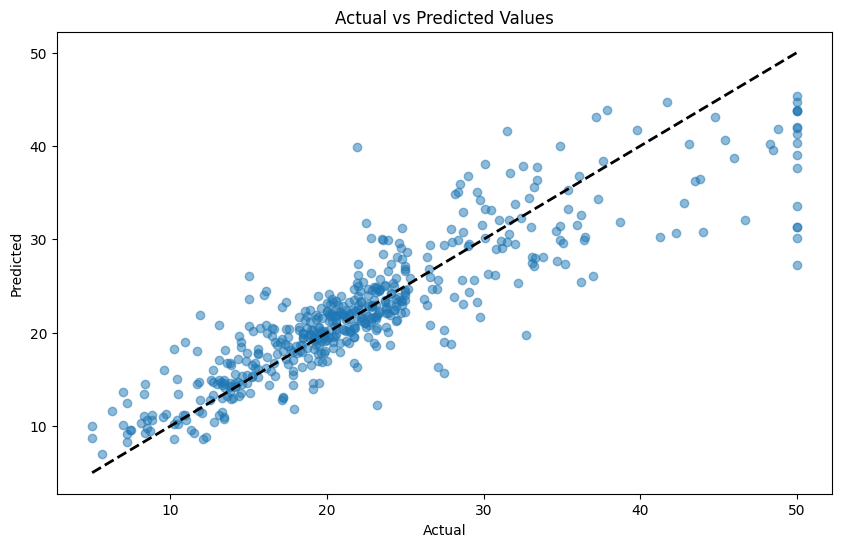

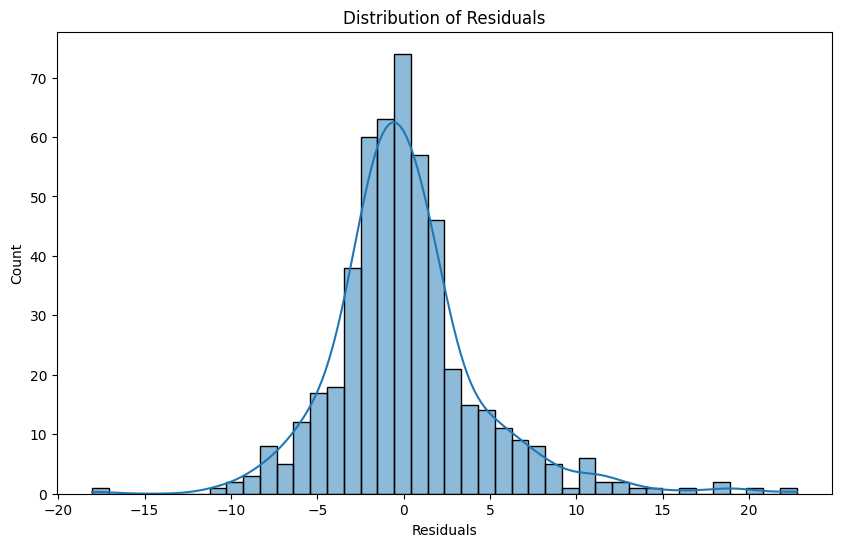

In [69]:
y = boston_housing_transformed_df['MEDV']
X = boston_housing_selected_components

random_forest_regressor = RandomForestRegressor(n_estimators=25, random_state=29)

cv = KFold(n_splits=5, shuffle=True, random_state=29)

y_pred = cross_val_predict(random_forest_regressor, X, y, cv=cv)

mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = sqrt(mse)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

cv_scores = cross_val_score(random_forest_regressor, X, y, cv=cv, scoring=make_scorer(mean_squared_error, greater_is_better=False))

cv_scores = -cv_scores

print(f"Cross-Validation Mean Squared Error: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Values')
plt.show()

residuals = y - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals')
plt.show()


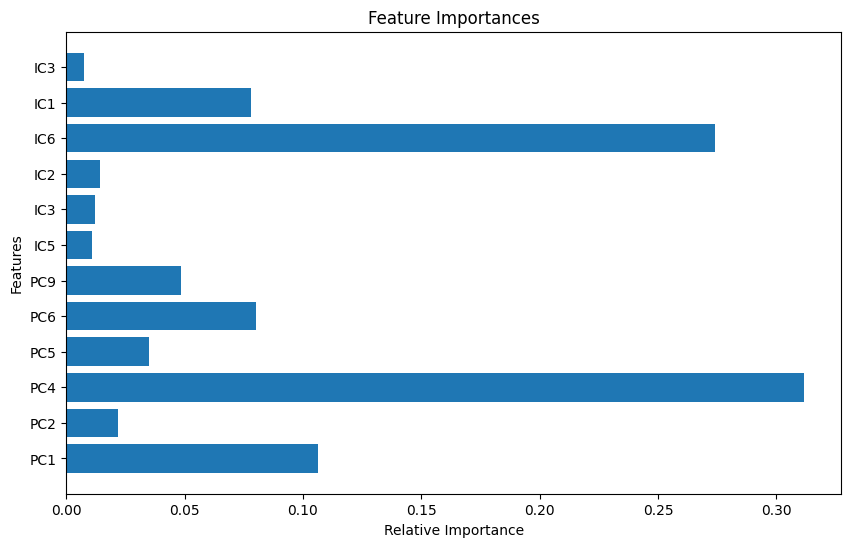

In [70]:
# Get feature importances and plot
random_forest_regressor.fit(X, y)
feature_importances = random_forest_regressor.feature_importances_
features = X.columns
indices = range(len(features))

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.barh(indices, feature_importances, align="center")
plt.yticks(indices, features)
plt.xlabel("Relative Importance")
plt.ylabel("Features")
plt.show()

Mean Squared Error: 25.41
R-squared: 0.70
Mean Absolute Error: 3.50
Root Mean Squared Error: 5.04
Cross-Validation Mean Squared Error: 25.42 ± 2.55


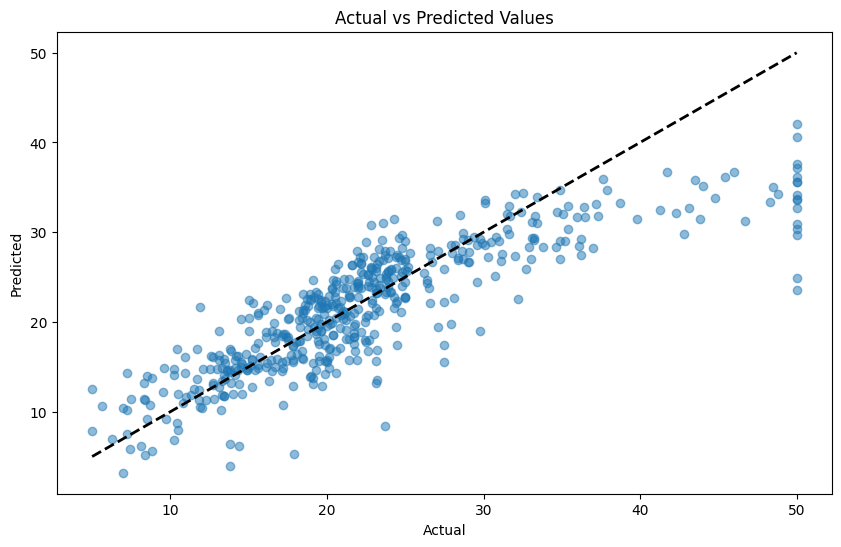

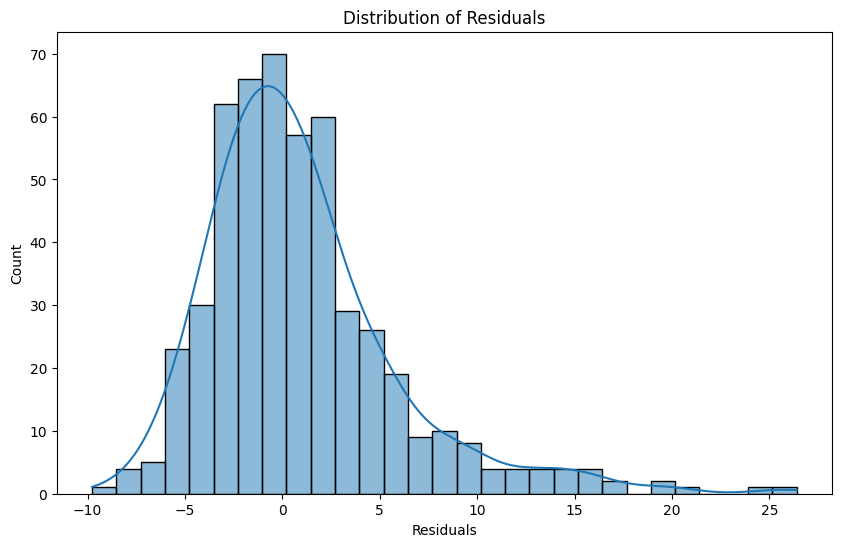

In [71]:
y = boston_housing_transformed_df['MEDV']
X = boston_housing_selected_components

svr = SVR(kernel='linear')

cv = KFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(svr, X, y, cv=cv)

mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = sqrt(mse)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

cv_scores = cross_val_score(svr, X, y, cv=cv, scoring=make_scorer(mean_squared_error, greater_is_better=False))
cv_scores = -cv_scores

print(f"Cross-Validation Mean Squared Error: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Values')
plt.show()

residuals = y - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals')
plt.show()

# Second Approach

In [27]:
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [28]:
boston_housing_transformed_second = boston_housing_transformed_df.copy()

In [29]:
y = boston_housing_transformed_second["MEDV"]
X = boston_housing_transformed_second.drop("MEDV", axis=1)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

**1 to 10 number of neighbors were tested and 3 showed the best results**

Mean Squared Error: 15.41
R-squared: 0.80
Mean Absolute Error: 2.75
Root Mean Squared Error: 7.38



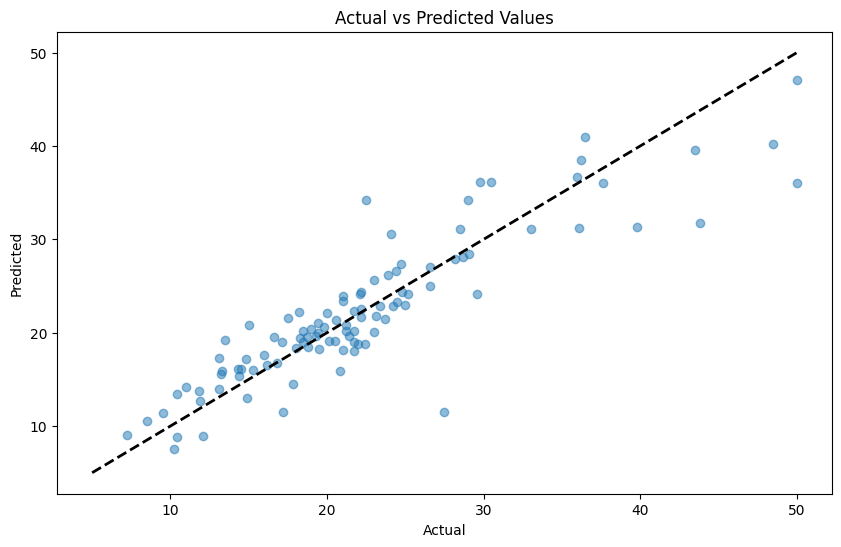

In [31]:
knn_reg = KNeighborsRegressor(n_neighbors=3)
knn_reg.fit(X_train, y_train)
knn_reg_pred = knn_reg.predict(X_test)

# Calculate evaluation metrics
mse_knn = mean_squared_error(y_test, knn_reg_pred)
r2_knn = r2_score(y_test, knn_reg_pred)
mae_knn = mean_absolute_error(y_test, knn_reg_pred)
rmse_knn = sqrt(mse)

# Display metrics
print(f"Mean Squared Error: {mse_knn:.2f}")
print(f"R-squared: {r2_knn:.2f}")
print(f"Mean Absolute Error: {mae_knn:.2f}")
print(f"Root Mean Squared Error: {rmse_knn:.2f}")
print("")

# Visualization of predicted vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, knn_reg_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Values')
plt.show()


Mean Squared Error: 7.76
R-squared: 0.90
Mean Absolute Error: 2.00
Root Mean Squared Error: 7.38



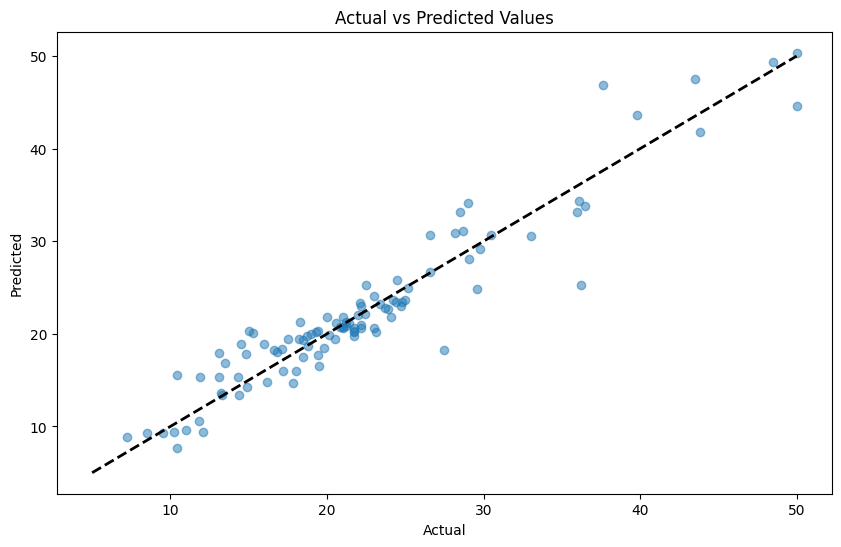

In [32]:
gbr_reg = GradientBoostingRegressor(n_estimators=100, random_state=29)
gbr_reg.fit(X_train, y_train)
gbr_reg_pred = gbr_reg.predict(X_test)

# Calculate evaluation metrics
mse_gbr = mean_squared_error(y_test, gbr_reg_pred)
r2_gbr = r2_score(y_test, gbr_reg_pred)
mae_gbr = mean_absolute_error(y_test, gbr_reg_pred)
rmse_gbr = sqrt(mse)

# Display metrics
print(f"Mean Squared Error: {mse_gbr:.2f}")
print(f"R-squared: {r2_gbr:.2f}")
print(f"Mean Absolute Error: {mae_gbr:.2f}")
print(f"Root Mean Squared Error: {rmse_gbr:.2f}")
print("")

# Visualization of predicted vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, gbr_reg_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Values')
plt.show()

# Third Approach


##Imports

In [33]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

##Training

In [34]:
bh_third = boston_housing_transformed_df.copy()

#Separate features
X = bh_third.drop(columns=['MEDV'])
y = bh_third['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

##Predictions
y_pred = dt_model.predict(X_test)

##Evaluation

In [35]:
mae_dt = mean_absolute_error(y_test, y_pred)
mse_dt = mean_squared_error(y_test, y_pred)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dt:.2f}")
print(f"R-squared (R2): {r2_dt:.2f}")

Mean Absolute Error (MAE): 3.35
Mean Squared Error (MSE): 24.76
Root Mean Squared Error (RMSE): 4.98
R-squared (R2): 0.67


##Visualisation

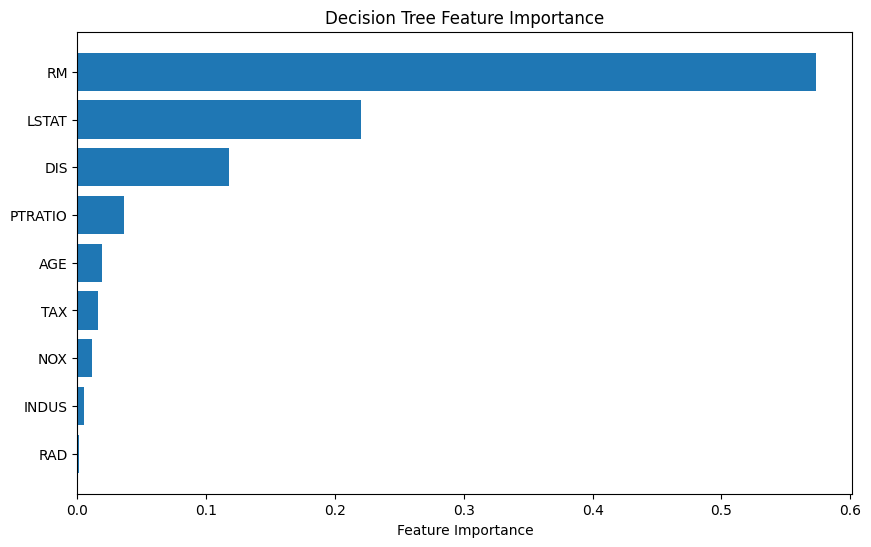

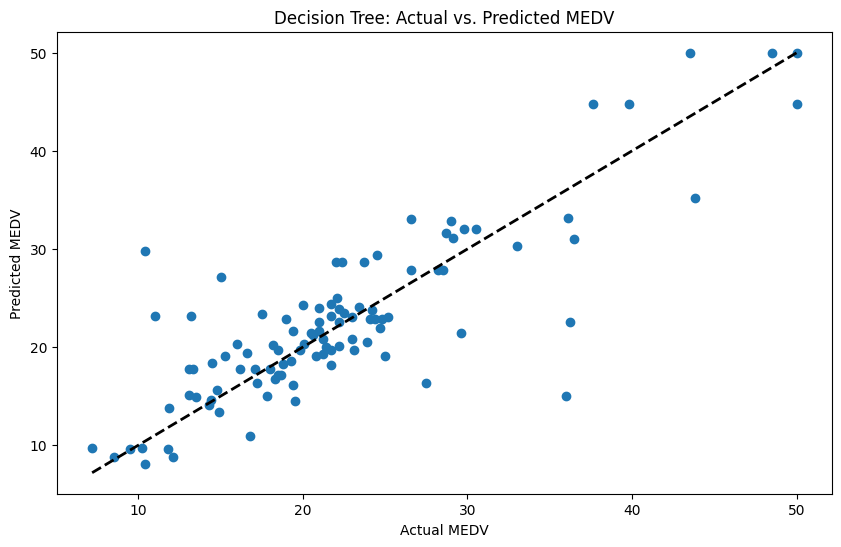

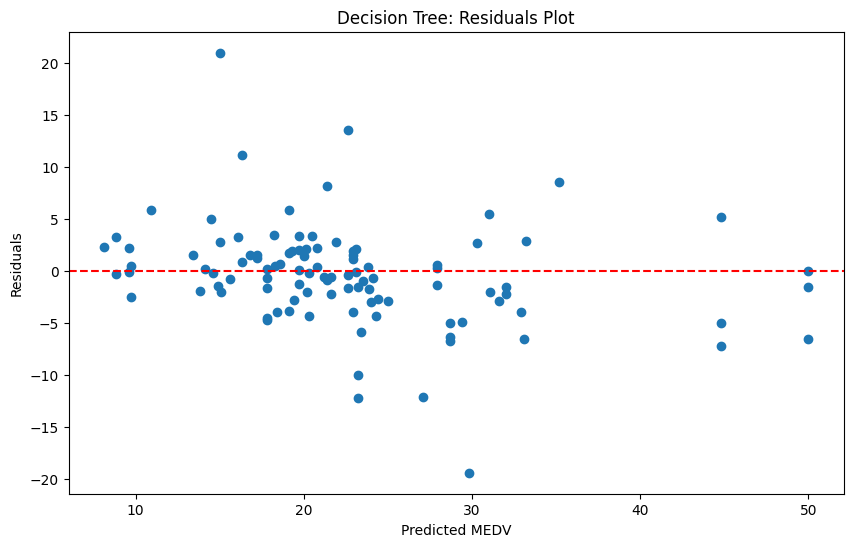

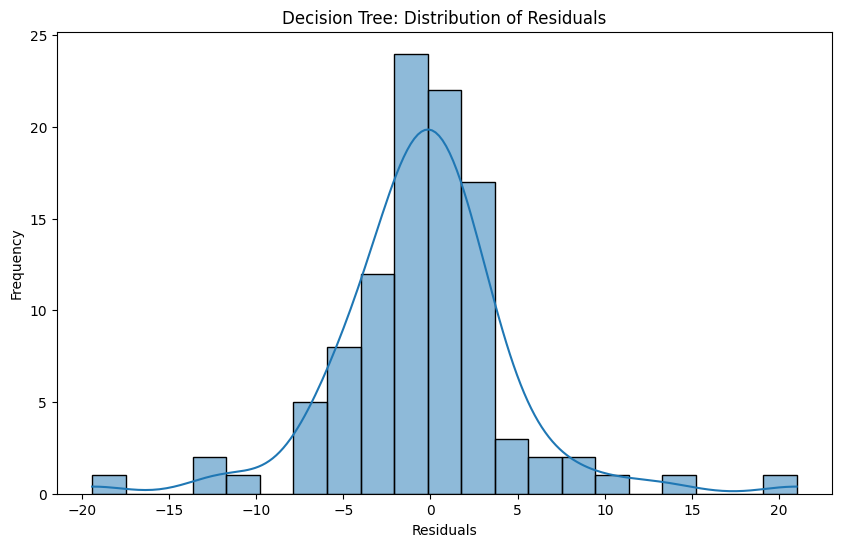

In [36]:
#DT feature importance
plt.figure(figsize=(10, 6))
feature_importance = dt_model.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X_train.columns)[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Decision Tree Feature Importance')
plt.show()

#Actual vs Predicted plot for DT
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual MEDV')
plt.ylabel('Predicted MEDV')
plt.title('Decision Tree: Actual vs. Predicted MEDV')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()

#Residuals plot for DT
residuals_dt = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals_dt)
plt.xlabel('Predicted MEDV')
plt.ylabel('Residuals')
plt.title('Decision Tree: Residuals Plot')
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

#Distribution of residuals for DT
plt.figure(figsize=(10, 6))
sns.histplot(residuals_dt, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Decision Tree: Distribution of Residuals')
plt.show()

#Model comparisons

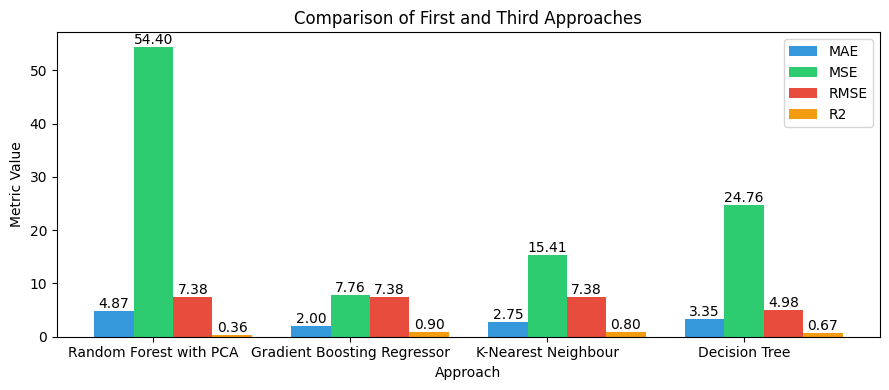

In [37]:
metrics_df = pd.DataFrame({
    'Approach': ['Random Forest with PCA', 'Gradient Boosting Regressor', 'K-Nearest Neighbour', 'Decision Tree'],
    'MAE': [mae, mae_gbr, mae_knn, mae_dt],
    'MSE': [mse, mse_gbr, mse_knn, mse_dt],
    'RMSE': [rmse, rmse_gbr, rmse_knn, rmse_dt],
    'R2': [r2, r2_gbr, r2_knn, r2_dt]
})

#Visualize the comparison
plt.figure(figsize=(9, 4))
bar_width = 0.2
index = np.arange(len(metrics_df['Approach']))

bar1 = plt.bar(index, metrics_df['MAE'], bar_width, label='MAE', color='#3498db')  # Vibrant blue
bar2 = plt.bar(index + bar_width, metrics_df['MSE'], bar_width, label='MSE', color='#2ecc71')  # Vibrant green
bar3 = plt.bar(index + 2 * bar_width, metrics_df['RMSE'], bar_width, label='RMSE', color='#e74c3c')  # Vibrant red
bar4 = plt.bar(index + 3 * bar_width, metrics_df['R2'], bar_width, label='R2', color='#f39c12')  # Vibrant orange

for bar in bar1:
    plt.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height(), f'{bar.get_height():.2f}', ha='center', va='bottom')
for bar in bar2:
    plt.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height(), f'{bar.get_height():.2f}', ha='center', va='bottom')
for bar in bar3:
    plt.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height(), f'{bar.get_height():.2f}', ha='center', va='bottom')
for bar in bar4:
    plt.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height(), f'{bar.get_height():.2f}', ha='center', va='bottom')

plt.xlabel('Approach')
plt.ylabel('Metric Value')
plt.title('Comparison of First and Third Approaches')
plt.xticks(index + bar_width, metrics_df['Approach'])
plt.legend()
plt.tight_layout()
plt.show()

# Discussion

The best solution to this problem involved using a Gradient Boosting Regressor without applying Principal Component Analysis (PCA). Only the initial three columns were dropped due to a high percentage of zero values. This model achieved a 29% higher R² score than the worst-performing model (Random Forest with PCA) and performed 10% better than the second-best model.


The different strategies used during the data processing phase impacted the overall performance of the models. The implementation of Principal Component Analysis (PCA) did not improve the performance metrics of the Random Forest model.

Additionally, while setting a fixed random state ensures reproducibility, it doesn't account for variability in model performance due to random splits in the training and testing data. Training models multiple times using different random seeds and comparing the average or median performance would provide a more accurate representation of each model's capability. This could mitigate the effects of a lucky or unlucky split in the data.